# Scikit-learn crash course

In [2]:
from sklearn.datasets import fetch_california_housing

In [6]:
X, y = fetch_california_housing(return_X_y=True) # load directly the features and the output

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = KNeighborsRegressor()

In [29]:
pipe = Pipeline([
    ("Scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=1))
])

In [30]:
pipe.fit(X, y)

Pipeline(steps=[('Scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=1))])

In [33]:
pred = pipe.predict(X)
pipe.get_params()

{'memory': None,
 'steps': [('Scaler', StandardScaler()),
  ('model', KNeighborsRegressor(n_neighbors=1))],
 'transform_input': None,
 'verbose': False,
 'Scaler': StandardScaler(),
 'model': KNeighborsRegressor(n_neighbors=1),
 'Scaler__copy': True,
 'Scaler__with_mean': True,
 'Scaler__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 1,
 'model__p': 2,
 'model__weights': 'uniform'}

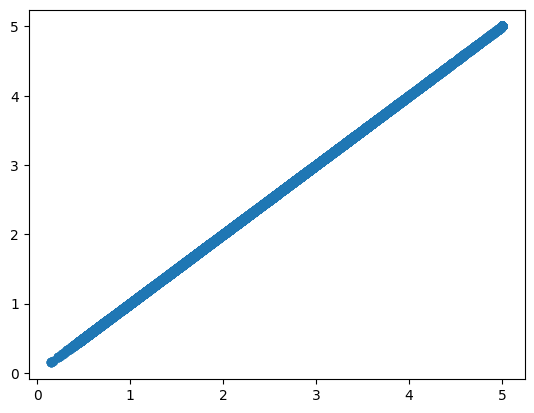

In [32]:
import matplotlib.pyplot as plt

plt.scatter(pred, y)

Through the pipeline, the data is first of all preprocessed/scaled in order to be fitted well by the model.
The model can even become better when we choose the right parameters but there, it only gives the impression to perform well but it doesn't because it only saves the data values, by using the ***GridSearchCV***, we split the model in training and testing data and through a mecanism called ***Cross-Validation (CV):*** our system looks for the best parameters (according to the model performance)

In [39]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

model = GridSearchCV(estimator=pipe, 
                   param_grid={"model__n_neighbors": [1,2,3,4,5,6,7,8,9,10]},
                   cv=3)

In [40]:
model.fit(X, y)
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.039992,0.004812,0.808614,0.034263,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.041230,0.005302,1.012576,0.139840,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.047357,0.002418,1.008792,0.102404,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.046558,0.006209,1.149893,0.070775,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.044008,0.000716,1.203477,0.074010,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.045585,0.002904,1.141827,0.126886,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.041966,0.001654,1.203957,0.087919,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.042874,0.002242,1.183676,0.074261,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.038797,0.012815,1.232134,0.136985,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.043594,0.007524,1.327664,0.120668,10,{'model__n_neighbors': 10},0.573760,0.595831,0.532973,0.567522,0.026038,1


In [41]:
print(fetch_california_housing()["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [43]:
pipe = Pipeline([
    ("Scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.get_params()

{'memory': None,
 'steps': [('Scaler', StandardScaler()), ('model', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'Scaler': StandardScaler(),
 'model': LinearRegression(),
 'Scaler__copy': True,
 'Scaler__with_mean': True,
 'Scaler__with_std': True,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__n_jobs': None,
 'model__positive': False}

In [45]:
model = GridSearchCV(estimator=pipe, 
                   param_grid={"model__n_jobs": [1,2,3,4,5],
                              "model__fit_intercept": [True, False],
                              "model__positive": [True, False]},
                   cv=3)

In [47]:
model.fit(X, y)
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__fit_intercept,param_model__n_jobs,param_model__positive,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.013283,0.001215,0.003110,0.000805,True,1,True,"{'model__fit_intercept': True, 'model__n_jobs'...",0.497821,0.496286,0.444685,0.479597,0.024694,6
1,0.012505,0.002314,0.002677,0.000521,True,1,False,"{'model__fit_intercept': True, 'model__n_jobs'...",0.555021,0.588378,0.585446,0.576282,0.015081,1
2,0.013002,0.000305,0.003505,0.000717,True,2,True,"{'model__fit_intercept': True, 'model__n_jobs'...",0.497821,0.496286,0.444685,0.479597,0.024694,6
3,0.015474,0.001416,0.003349,0.000462,True,2,False,"{'model__fit_intercept': True, 'model__n_jobs'...",0.555021,0.588378,0.585446,0.576282,0.015081,1
4,0.013071,0.000727,0.003411,0.000424,True,3,True,"{'model__fit_intercept': True, 'model__n_jobs'...",0.497821,0.496286,0.444685,0.479597,0.024694,6
5,0.014034,0.001851,0.003349,0.000459,True,3,False,"{'model__fit_intercept': True, 'model__n_jobs'...",0.555021,0.588378,0.585446,0.576282,0.015081,1
6,0.013023,0.002418,0.003258,0.000667,True,4,True,"{'model__fit_intercept': True, 'model__n_jobs'...",0.497821,0.496286,0.444685,0.479597,0.024694,6
7,0.014707,0.002766,0.002822,0.001739,True,4,False,"{'model__fit_intercept': True, 'model__n_jobs'...",0.555021,0.588378,0.585446,0.576282,0.015081,1
8,0.012974,0.001075,0.003411,0.000434,True,5,True,"{'model__fit_intercept': True, 'model__n_jobs'...",0.497821,0.496286,0.444685,0.479597,0.024694,6
9,0.014729,0.002828,0.003343,0.000494,True,5,False,"{'model__fit_intercept': True, 'model__n_jobs'...",0.555021,0.588378,0.585446,0.576282,0.015081,1


# Preprocessing

In [89]:
from sklearn.preprocessing import OneHotEncoder

In [92]:
arr = np.array([
    "low", 
    "low",
    "high",
    "medium"
]).reshape(-1, 1)

arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [98]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [100]:
enc.transform([["zero"]])

array([[0., 0., 0.]])

**Data preprocessing:** is a very important step to improve model performances. It's a crucial step which consists to clean and transform data in order to make them exploitable for an algorithm and to improve its performances. There are several preprocessing techniques depending on the input data we have:

## 1. For numerical data (Scaling)

- StandardScaler : center and reduce data (mean = 0, std = 1).It's the default choice for the majority of algorithms (Regression, SVM, PCA).
- MinMaxScaler : Transform data in order to calibrate them in a fix time interval(generally between 0 and 1).Ideal for neural networks or distance sensitive algorithms(KNN). Fail for big outliers
- RobustScaler : Scale using median and interquantiale range(IQR).Only if your data contains many unerasable outliers.
- PowerTransformer : Apply a transformation(Box-Cox or Yeo-Johnson) to make data more gaussian-like(bell plot).To stabilise asymetric std

## 2. For categorical data(Encoding)
   
- OneHotEncoder : creates a binary column for each category.Key parameter : drop='first', or handle_unknown='ignore' to handle new category.
- OrdinalEncoder : convert textual categories into ordinal integers(0, 1, 2, etc.).Usage : Dedicated to explanatory varaibles(\(X\)) which possess a natural hierarchy(ex: ['Low', 'Medium', 'High']).
- LabelEncoder : Identical to OrdinalEncoder but only designed for the target variable (\(y\)) in classification problems.
- TargetEncoder : Replace the category by the mean of the corresponding  target variable. Very efficient for strong cardinality variable (ex: postal box or car brand).

# Metrics

In [102]:
df = pd.read_csv("./datasets/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [104]:
X = df.drop(columns=["Time", "Amount", "Class"]).values
y = df["Class"].values
print(f"#X shape:{X.shape} #y shape:{y.shape}, #Fraud cases: {y.sum()}")

#X shape:(284807, 28) #y shape:(284807,), #Fraud cases: 492


In [108]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={0:1, 1:2}, max_iter=1000)
model.fit(X, y).predict(X).sum()

np.int64(434)

In [111]:
model = GridSearchCV(estimator=LogisticRegression(max_iter=1000),
            param_grid={"class_weight":[{0:1, 1:v} for v in range(1,4)]},
            cv=4,
            n_jobs=-1)
model.fit(X,y)

GridSearchCV(cv=4, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2},
                                          {0: 1, 1: 3}]})

In [112]:
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,2.330585,0.658798,0.031490,0.010170,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.999228,0.998890,0.999228,0.998919,0.999066,0.000162,3
1,2.781430,0.637523,0.050634,0.036198,"{0: 1, 1: 2}","{'class_weight': {0: 1, 1: 2}}",0.999270,0.999157,0.999171,0.999031,0.999157,0.000085,2
2,2.244207,0.332672,0.021817,0.003061,"{0: 1, 1: 3}","{'class_weight': {0: 1, 1: 3}}",0.999199,0.999256,0.999199,0.999115,0.999192,0.000050,1


In [115]:
from sklearn.metrics import precision_score, recall_score, make_scorer

precision_score(y, model.predict(X))

0.8177874186550976

In [136]:
def min_recall_precision(y_true, y_pred):
    return min(recall_score(y_true, y_pred), precision_score(y_true, y_pred))

model = GridSearchCV(estimator=LogisticRegression(max_iter=1000),
            param_grid={"class_weight":[{0:1, 1:v} for v in np.linspace(1,20,30)]},
            scoring={"precision": make_scorer(precision_score), "recall": make_scorer(recall_score)},
            cv=10,
            n_jobs=-1,
            return_train_score=True,
            refit=False)
model.fit(X,y)
df = pd.DataFrame(model.cv_results_)

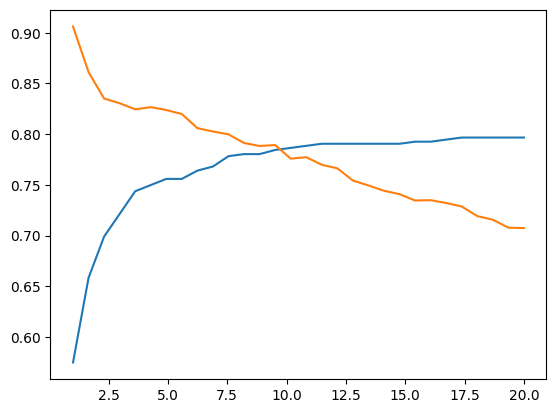

In [137]:
for score in ["mean_test_recall", "mean_test_precision"]:
    plt.plot([_[1] for _ in df["param_class_weight"]], df[score], label=score)

In [139]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification

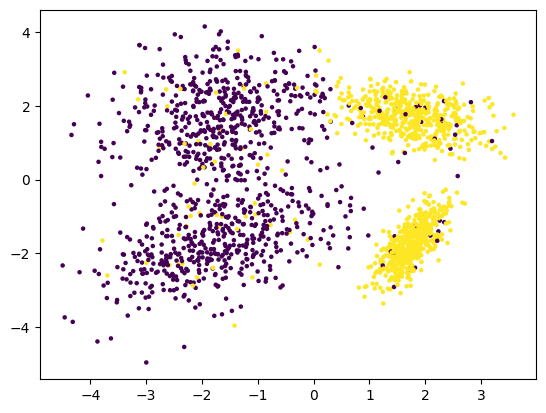

In [173]:
X, y = make_classification(n_samples=2000, n_features=2,
                          n_redundant=0, random_state=21,
                          class_sep=1.75, flip_y=0.1)
plt.scatter(X[:,0], X[:, 1], c=y, s=5)

In [174]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = VotingClassifier(estimators=[("clf1", clf1), ("clf2", clf2)],
                       voting="soft",
                       weights=[0.5, 0.5])

clf3.fit(X, y)

VotingClassifier(estimators=[('clf1', LogisticRegression()),
                             ('clf2', KNeighborsClassifier())],
                 voting='soft', weights=[0.5, 0.5])

In [175]:
from sklego.meta import Thresholder
from sklearn.metrics import accuracy_score

pipe = Pipeline([(
    "model", Thresholder(LogisticRegression(solver="lbfgs"), threshold=0.10)
)])

model = GridSearchCV(estimator = pipe, 
                    param_grid={"model__threshold": np.linspace(0.1,0.9,50)},
                    scoring={"precision": make_scorer(precision_score),
                            "recall": make_scorer(recall_score),
                            "accuracy": make_scorer(accuracy_score)},
                    refit="precision",
                    cv=5)

model.fit(X, y)
df = pd.DataFrame(model.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__threshold,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,std_test_recall,rank_test_recall,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
0,0.007307,0.001832,0.008996,0.002366,0.100000,{'model__threshold': 0.1},0.782258,0.758755,0.787149,0.749035,...,0.003698,1,0.8450,0.8250,0.8500,0.8150,0.8125,0.8295,0.015362,50
1,0.005395,0.000798,0.008512,0.001007,0.116327,{'model__threshold': 0.1163265306122449},0.804979,0.776892,0.796748,0.772908,...,0.003677,2,0.8625,0.8400,0.8575,0.8350,0.8300,0.8450,0.012748,48
2,0.005092,0.001364,0.006796,0.001164,0.132653,{'model__threshold': 0.1326530612244898},0.834783,0.795918,0.805785,0.782258,...,0.003765,3,0.8800,0.8550,0.8625,0.8425,0.8350,0.8550,0.015732,47
3,0.006371,0.000803,0.008955,0.000807,0.148980,{'model__threshold': 0.1489795918367347},0.842105,0.804979,0.808333,0.795082,...,0.002068,4,0.8850,0.8600,0.8625,0.8525,0.8525,0.8625,0.011937,45
4,0.005390,0.000499,0.007783,0.000995,0.165306,{'model__threshold': 0.1653061224489796},0.860987,0.811715,0.810924,0.815126,...,0.002474,5,0.8975,0.8650,0.8625,0.8675,0.8650,0.8715,0.013096,44
5,0.005798,0.001156,0.007925,0.000904,0.181633,{'model__threshold': 0.1816326530612245},0.868778,0.822034,0.831897,0.818565,...,0.002474,5,0.9025,0.8725,0.8775,0.8700,0.8700,0.8785,0.012309,43
6,0.006388,0.000798,0.008941,0.001028,0.197959,{'model__threshold': 0.1979591836734694},0.872727,0.832618,0.838428,0.832618,...,0.003966,7,0.9050,0.8800,0.8800,0.8800,0.8775,0.8845,0.010296,41
7,0.005328,0.001048,0.008990,0.001089,0.214286,{'model__threshold': 0.2142857142857143},0.872727,0.843478,0.845815,0.850877,...,0.003966,7,0.9050,0.8875,0.8850,0.8925,0.8875,0.8915,0.007176,40
8,0.005992,0.000620,0.007200,0.000953,0.230612,{'model__threshold': 0.2306122448979592},0.876712,0.850220,0.853333,0.854626,...,0.003701,9,0.9075,0.8900,0.8900,0.8950,0.8925,0.8950,0.006519,38
9,0.005141,0.000255,0.007992,0.000632,0.246939,{'model__threshold': 0.2469387755102041},0.893023,0.857778,0.864865,0.862222,...,0.003701,9,0.9175,0.8950,0.8975,0.9000,0.8975,0.9015,0.008155,37


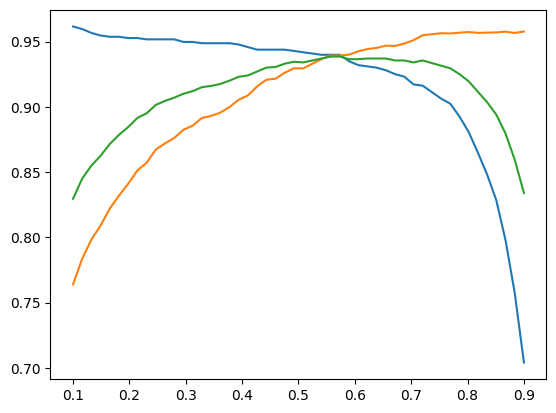

In [176]:
for score in ["mean_test_recall", "mean_test_precision", "mean_test_accuracy"]:
    plt.plot([_ for _ in df["param_model__threshold"]], df[score], label=score)

In [177]:
df[df["rank_test_accuracy"]==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__threshold,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,std_test_recall,rank_test_recall,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
28,0.005192,0.000757,0.009309,0.000894,0.557143,{'model__threshold': 0.5571428571428572},0.964286,0.927536,0.94,0.913876,...,0.008506,28,0.95,0.935,0.9325,0.925,0.95,0.9385,0.00995,1
29,0.004713,0.000743,0.007814,0.001168,0.573469,{'model__threshold': 0.573469387755102},0.964286,0.927536,0.94,0.913876,...,0.008506,28,0.95,0.935,0.9325,0.925,0.95,0.9385,0.00995,1


# HUMAN LEARNING

In [178]:
from hulearn.datasets import load_titanic

In [179]:
df  = load_titanic(as_frame=True)
X, y = df.drop(columns=["survived", "name"]), df["survived"] 
df.head(10)

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0
5,0,1,"McCarthy, Mr. Timothy J",male,54.0,51.8625,0,0
6,0,3,"Palsson, Master. Gosta Leonard",male,2.0,21.0750,3,1
7,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,11.1333,0,2
8,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,30.0708,1,0
9,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,16.7000,1,1


In [180]:
def fare_based(df, threshold=10):
    return np.array(df["fare"]>threshold).astype(int)

In [181]:
from hulearn.classification import FunctionClassifier

mod = FunctionClassifier(fare_based, threshold=10)

In [182]:
model = GridSearchCV(mod,
                    cv=2,
                    param_grid={"threshold": np.linspace(0,100,50)},
                    scoring={"precision": make_scorer(precision_score),
                            "recall": make_scorer(recall_score),
                            "accuracy": make_scorer(accuracy_score)},
                    refit="accuracy")
model.fit(X, y)

GridSearchCV(cv=2,
             estimator=FunctionClassifier(func=<function fare_based at 0x000001FC83F391B0>,
                                          threshold=10),
             param_grid={'threshold': array([  0.        ,   2.04081633,   4.08163265,   6.12244898,
         8.16326531,  10.20408163,  12.24489796,  14.28571429,
        16.32653061,  18.36734694,  20.40816327,  22.44897959,
        24.48979592,  26.53061224,  28.57142857,  30.6122449 ,
        32.65306122,  34.69387755,  36.7346938...
        73.46938776,  75.51020408,  77.55102041,  79.59183673,
        81.63265306,  83.67346939,  85.71428571,  87.75510204,
        89.79591837,  91.83673469,  93.87755102,  95.91836735,
        97.95918367, 100.        ])},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'precision': make_scorer(precision_score, response_method='predict'),
                      'recall': make_scorer(recall_score, response_method='predict')})

In [186]:
df = pd.DataFrame(model.cv_results_)

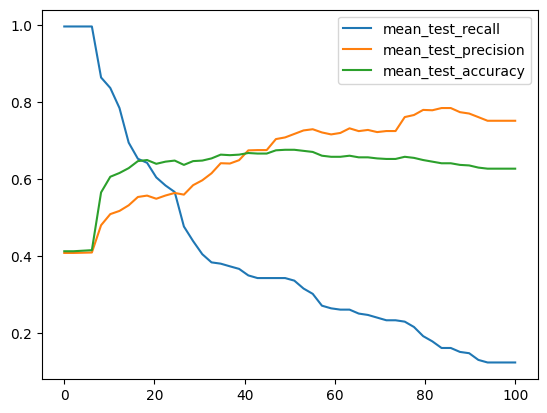

In [189]:
for score in ["mean_test_recall", "mean_test_precision", "mean_test_accuracy"]:
    plt.plot([_ for _ in df["param_threshold"]], df[score], label=score)

plt.legend()